In [6]:
import pandas as pd

# Carregar os dados de vendas
df_vendas = pd.read_csv('../data/vendas_2023_2024.csv')

# Verificar valores nulos por coluna
nulos_por_coluna = df_vendas.isnull().sum()

# Calcular o percentual de nulos 
percentual_nulos = (df_vendas.isnull().sum() / len(df_vendas)) * 100

# Criar uma tabelinha de resumo para você analisar
resumo_nulos = pd.DataFrame({
    'Total de Nulos': nulos_por_coluna,
    'Percentual (%)': percentual_nulos
})

print("--- Auditoria de Valores Nulos ---")
print(resumo_nulos)

# Verificar se existem linhas 100% duplicadas
duplicados = df_vendas.duplicated().sum()
print(f"\nLinhas totalmente duplicadas encontradas: {duplicados}")

--- Auditoria de Valores Nulos ---
            Total de Nulos  Percentual (%)
id                       0             0.0
id_client                0             0.0
id_product               0             0.0
qtd                      0             0.0
total                    0             0.0
sale_date                0             0.0

Linhas totalmente duplicadas encontradas: 0


In [10]:
import pandas as pd

# 1. Carga dos dados originais
df_produtos = pd.read_csv('../data/produtos_raw.csv')

# --- PARTE 1: Padronização das Categorias ---
def padronizar_categoria(txt):
    # Transformamos em string, removemos espaços e colocamos em minúsculo
    txt = str(txt).lower().strip()
    
    # Lógica de mapeamento por radical da palavra
    if 'eletr' in txt:
        return 'eletrônicos'
    elif 'prop' in txt:
        return 'propulsão'
    elif 'ancor' in txt or 'encor' in txt:
        return 'ancoragem'
    else:
        return 'outros'

df_produtos['actual_category'] = df_produtos['actual_category'].apply(padronizar_categoria)

# --- PARTE 2: Conversão de Valores para Numérico ---
# O parâmetro 'coerce' transforma erros (como textos no meio de números) em valores nulos (NaN)
df_produtos['price'] = pd.to_numeric(df_produtos['price'], errors='coerce')

# --- PARTE 3: Remoção de Duplicatas ---
# Removemos linhas idênticas para garantir a integridade
df_produtos = df_produtos.drop_duplicates()

# Exportação do arquivo higienizado
df_produtos.to_csv('../data/produtos_limpos.csv', index=False)

# Verificação dos resultados
print("Categorias padronizadas com sucesso:")
print(df_produtos['actual_category'].unique())
print(f"\nTotal de registros após higienização: {len(df_produtos)}")

Categorias padronizadas com sucesso:
<StringArray>
['eletrônicos', 'outros', 'propulsão', 'ancoragem']
Length: 4, dtype: str

Total de registros após higienização: 152


In [11]:
import pandas as pd

# Carregamos o arquivo original novamente para comparar
df_original = pd.read_csv('../data/produtos_raw.csv')

# Carregamos o arquivo que você acabou de limpar
df_limpo = pd.read_csv('../data/produtos_limpos.csv')

# Cálculo da diferença
total_original = len(df_original)
total_apos_limpeza = len(df_limpo)
duplicados_removidos = total_original - total_apos_limpeza

print(f"Total de registros originais: {total_original}")
print(f"Total de registros após limpeza: {total_apos_limpeza}")
print(f"Quantidade de produtos duplicados removidos: {duplicados_removidos}")

Total de registros originais: 157
Total de registros após limpeza: 152
Quantidade de produtos duplicados removidos: 5


In [5]:
import pandas as pd
import json

# 1. Carregamento do arquivo JSON
with open('../data/custos_importacao.json', 'r', encoding='utf-8') as f:
    dados_json = json.load(f)

lista_processada = []

# 2. Processamento da estrutura aninhada (Flattening)
for produto in dados_json:
    p_id = produto.get('product_id')
    p_name = produto.get('product_name')
    p_category = produto.get('category')
    
    # Utilizamos a chave correta identificada na inspeção: 'historic_data'
    historico = produto.get('historic_data', [])
    
    for item in historico:
        lista_processada.append({
            'product_id': int(p_id),
            'product_name': p_name,
            'category': p_category,
            'start_date': item.get('start_date'),
            'usd_price': float(item.get('usd_price'))
        })

# 3. Criação do DataFrame e Formatação Técnica
df_custos = pd.DataFrame(lista_processada)

# Tratamento da data para o padrão de banco de dados (AAAA-MM-DD)
df_custos['start_date'] = pd.to_datetime(df_custos['start_date'], dayfirst=True).dt.date

# 4. Exportação para CSV conforme solicitado pelo Gabriel
df_custos.to_csv('../data/custos_importacao_final.csv', index=False)

# Exibição do resultado para validação final
print("Processamento concluído com sucesso!")
print(f"Total de registros gerados: {len(df_custos)}")
print("\nPrimeiras linhas do novo arquivo:")
print(df_custos.head())

Processamento concluído com sucesso!
Total de registros gerados: 1260

Primeiras linhas do novo arquivo:
   product_id                 product_name     category  start_date  usd_price
0           1  Transponder AIS Maré Magnum  eletrônicos  2016-08-10   10583.63
1           1  Transponder AIS Maré Magnum  eletrônicos  2018-06-15    8778.36
2           1  Transponder AIS Maré Magnum  eletrônicos  2018-09-25    8023.87
3           1  Transponder AIS Maré Magnum  eletrônicos  2019-03-19    8772.78
4           1  Transponder AIS Maré Magnum  eletrônicos  2020-01-17    7918.18


In [3]:
import json

# Vamos ler apenas o primeiro item do seu JSON para descobrir os nomes das chaves
with open('../data/custos_importacao.json', 'r', encoding='utf-8') as f:
    dados_temp = json.load(f)

print("Estrutura do primeiro produto encontrado:")
print(dados_temp[0].keys())

# Vamos ver o que tem dentro do primeiro item para entender o histórico
primeiro_item = dados_temp[0]
for chave, valor in primeiro_item.items():
    if isinstance(valor, list):
        print(f"\nEncontrei uma lista na chave: '{chave}'")
        print(f"Exemplo do conteúdo dessa lista: {valor[0]}")

Estrutura do primeiro produto encontrado:
dict_keys(['product_id', 'product_name', 'category', 'historic_data'])

Encontrei uma lista na chave: 'historic_data'
Exemplo do conteúdo dessa lista: {'start_date': '10/08/2016', 'usd_price': 10583.63}


In [6]:
import pandas as pd

# Lendo o arquivo que acabamos de gerar
df_verificacao = pd.read_csv('../data/custos_importacao_final.csv')

# Contagem total de linhas
total_entradas = len(df_verificacao)

print(f"O arquivo CSV recebeu ao todo: {total_entradas} entradas de importação.")

O arquivo CSV recebeu ao todo: 1260 entradas de importação.


In [2]:
import pandas as pd
import sqlite3

# 1. Carregar as bases
df_vendas = pd.read_csv('../data/vendas_2023_2024.csv')
df_custos = pd.read_csv('../data/custos_importacao_final.csv')

# CORREÇÃO DEFINITIVA: Usamos format='mixed' para o Python identificar cada linha individualmente
df_vendas['sale_date'] = pd.to_datetime(df_vendas['sale_date'], dayfirst=True, format='mixed')
df_custos['start_date'] = pd.to_datetime(df_custos['start_date'], format='mixed')

# 2. Conexão em memória
conn = sqlite3.connect(':memory:')
df_vendas.to_sql('vendas', conn, index=False)
df_custos.to_sql('custos', conn, index=False)

# 3. SQL de Análise
query_4_1 = """
WITH base_calculada AS (
    SELECT 
        v.id_product,
        v.total AS receita_brl,
        v.qtd,
        c.usd_price,
        -- Cálculo do custo total usando o câmbio médio de 5.15
        (c.usd_price * 5.15 * v.qtd) AS custo_total_brl
    FROM vendas v
    INNER JOIN custos c ON v.id_product = c.product_id
    WHERE v.sale_date >= c.start_date
)
SELECT 
    id_product,
    ROUND(SUM(receita_brl), 2) AS receita_total_brl,
    ROUND(SUM(CASE WHEN receita_brl < custo_total_brl THEN (custo_total_brl - receita_brl) ELSE 0 END), 2) AS prejuizo_total_brl,
    ROUND((SUM(CASE WHEN receita_brl < custo_total_brl THEN (custo_total_brl - receita_brl) ELSE 0 END) / SUM(receita_brl)) * 100, 2) AS percentual_perda
FROM base_calculada
GROUP BY id_product
HAVING prejuizo_total_brl > 0
ORDER BY prejuizo_total_brl DESC
"""

df_resultado_final = pd.read_sql_query(query_4_1, conn)

print("--- RESULTADO FINAL DA ANÁLISE ---")
if not df_resultado_final.empty:
    print(df_resultado_final.head(10))
else:
    print("Atenção: Nenhum prejuízo encontrado ou erro no cruzamento de dados.")
    # Formata os números para duas casas decimais antes de imprimir
pd.options.display.float_format = '{:.2f}'.format
print(df_resultado_final.head(10))

--- RESULTADO FINAL DA ANÁLISE ---
   id_product  receita_total_brl  prejuizo_total_brl  percentual_perda
0          76       8.889522e+08        3.296975e+08             37.09
1          81       5.829719e+08        2.747711e+08             47.13
2          73       7.554693e+08        2.417000e+08             31.99
3          99       5.783390e+08        2.260344e+08             39.08
4          92       5.414280e+08        1.871125e+08             34.56
5          51       5.326159e+08        1.759234e+08             33.03
6          63       3.440859e+08        1.405088e+08             40.84
7         100       3.102234e+08        1.360767e+08             43.86
8          71       7.897660e+08        1.097970e+08             13.90
9          54       2.634389e+08        1.054253e+08             40.02
   id_product  receita_total_brl  prejuizo_total_brl  percentual_perda
0          76       888952232.10        329697542.84             37.09
1          81       582971888.85        27

In [13]:
%pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------- ----------------------- 3.4/8.1 MB 16.8 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 16.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 15.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 14.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   -------------------- ------------------- 3.7/7.0 MB 16.7 MB/s eta 0:00:01
   -------------------------------------- - 6.8/7.0 MB 16.8 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 15.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
print(df_vendas.columns)

Index(['id', 'id_client', 'id_product', 'qtd', 'total', 'sale_date'], dtype='str')


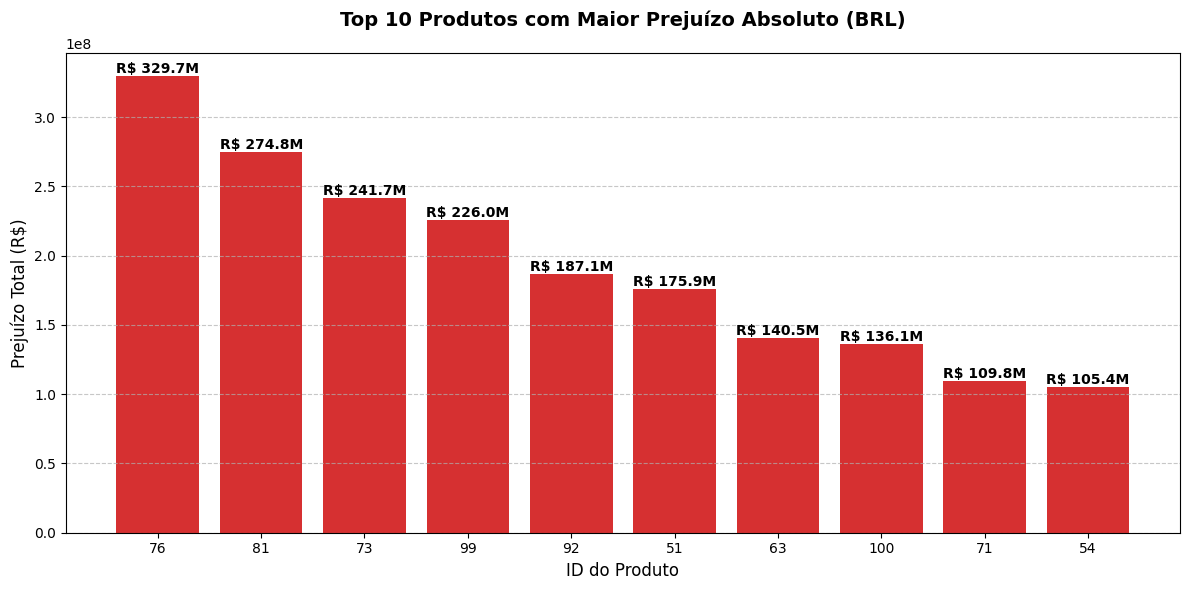

In [ ]:
import matplotlib.pyplot as plt

# 1. Preparar os dados a partir do resultado do seu SQL (visto no print 4 1 c.PNG)
# Filtramos os 10 maiores prejuízos
df_grafico = df_resultado_final.head(10).copy()

# 2. Configurar o estilo e tamanho do gráfico
plt.figure(figsize=(12, 6))
# Usamos 'prejuizo_total_brl' que é o nome da coluna no seu print 4 1 c.PNG
bars = plt.bar(df_grafico['id_product'].astype(str), 
               df_grafico['prejuizo_total_brl'], 
               color='#d63031') # Vermelho profissional

# 3. Adicionar títulos e legendas técnicas
plt.title('Top 10 Produtos com Maior Prejuízo Absoluto (BRL)', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('ID do Produto', fontsize=12)
plt.ylabel('Prejuízo Total (R$)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Adicionar os valores acima de cada barra em Milhões (M) para ficar limpo
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, 
             f'R$ {yval/1e6:.1f}M', 
             va='bottom', ha='center', fontsize=10, fontweight='bold')

# 5. Exibir o gráfico
plt.tight_layout()
plt.show()


In [8]:
import pandas as pd
import numpy as np

# Caminho corrigido: ../ sobe um nível e entra na pasta data
df_vendas = pd.read_csv('../data/vendas_2023_2024.csv')
df_produtos = pd.read_csv('../data/produtos_raw.csv')

# O restante do código permanece igual
df_vendas['sale_date'] = pd.to_datetime(df_vendas['sale_date'], format='mixed', dayfirst=True)

# ... (restante do código que já funcionou antes)

In [10]:
import pandas as pd
import numpy as np

# 1. Carregamento dos Dados com Caminho Relativo Corrigido
# Como o notebook está em /notebooks, precisamos voltar (..) e entrar em /data
try:
    df_vendas = pd.read_csv('../data/vendas_2023_2024.csv')
    df_produtos = pd.read_csv('../data/produtos_raw.csv')
    print("Arquivos carregados com sucesso!")
except FileNotFoundError:
    print("Erro: Verifique se os arquivos estão na pasta ../data/")

# 2. Tratamento de Data (Padrão Brasileiro e Datas Mistas)
df_vendas['sale_date'] = pd.to_datetime(df_vendas['sale_date'], format='mixed', dayfirst=True)

# 3. Filtro do Produto Alvo: Motor de Popa Yamaha Evo Dash 155HP
nome_produto = "Motor de Popa Yamaha Evo Dash 155HP"
# Localizando o ID do produto pelo nome para evitar erros de digitação manual
id_alvo = df_produtos[df_produtos['name'] == nome_produto]['code'].values[0]
df_motor = df_vendas[df_vendas['id_product'] == id_alvo].copy()

# 4. Criação da Série Temporal Diária (Incluindo dias com zero vendas)
data_inicio = df_vendas['sale_date'].min()
data_fim = pd.to_datetime('2024-01-31')
calendario = pd.DataFrame({'sale_date': pd.date_range(start=data_inicio, end=data_fim, freq='D')})

# Agrupando vendas por dia e garantindo que dias sem venda sejam 0 (Zero-Padding)
df_diario = df_motor.groupby('sale_date')['qtd'].sum().reset_index()
df_completo = pd.merge(calendario, df_diario, on='sale_date', how='left').fillna(0)

# 5. Modelo Baseline: Média Móvel de 7 dias (Sem Data Leakage)
# O shift(1) garante que a previsão de hoje use apenas os 7 dias ANTERIORES
df_completo['previsao'] = df_completo['qtd'].shift(1).rolling(window=7).mean()

# 6. Avaliação do Período de Teste (Janeiro de 2024)
periodo_teste = df_completo[(df_completo['sale_date'] >= '2024-01-01') & (df_completo['sale_date'] <= '2024-01-31')].copy()

# Removendo valores nulos (os primeiros 7 dias do histórico não têm média móvel)
periodo_teste = periodo_teste.dropna(subset=['previsao'])

# Cálculo do MAE (Erro Médio Absoluto)
mae = np.mean(np.abs(periodo_teste['qtd'] - periodo_teste['previsao']))

print(f"\n--- RELATÓRIO DE PREVISÃO PARA O SR. ALMIR ---")
print(f"Produto: {nome_produto}")
print(f"Métrica MAE (Jan/2024): {mae:.4f}")
print("-" * 45)
print("Amostra das Previsões Diárias (Primeiros 10 dias de Janeiro):")
print(periodo_teste[['sale_date', 'qtd', 'previsao']].head(10))

Arquivos carregados com sucesso!

--- RELATÓRIO DE PREVISÃO PARA O SR. ALMIR ---
Produto: Motor de Popa Yamaha Evo Dash 155HP
Métrica MAE (Jan/2024): 1.6406
---------------------------------------------
Amostra das Previsões Diárias (Primeiros 10 dias de Janeiro):
     sale_date   qtd  previsao
365 2024-01-01   0.0  0.000000
366 2024-01-02   0.0  0.000000
367 2024-01-03   0.0  0.000000
368 2024-01-04   0.0  0.000000
369 2024-01-05  10.0  0.000000
370 2024-01-06   0.0  1.428571
371 2024-01-07   0.0  1.428571
372 2024-01-08   0.0  1.428571
373 2024-01-09   0.0  1.428571
374 2024-01-10   0.0  1.428571


In [14]:
import pandas as pd
import numpy as np

# 1. Carregamento Seguro (usando o caminho relativo que já sabemos que funciona)
try:
    df_vendas = pd.read_csv('../data/vendas_2023_2024.csv')
    df_produtos = pd.read_csv('../data/produtos_raw.csv')
except:
    df_vendas = pd.read_csv('vendas_2023_2024.csv')
    df_produtos = pd.read_csv('produtos_raw.csv')

# 2. Construção da Matriz Usuário x Produto
# CORREÇÃO: Usamos 'id_client' (exatamente como detectado no seu arquivo)
matriz_usuario_item = df_vendas.pivot_table(index='id_client', 
                                           columns='id_product', 
                                           values='qtd', 
                                           aggfunc=lambda x: 1 if len(x) > 0 else 0).fillna(0)

# 3. Cálculo de Similaridade (Pearson)
matriz_similaridade = matriz_usuario_item.corr(method='pearson')

# 4. Produto de Referência
nome_referencia = "GPS Garmin Vortex Maré Drift"
id_referencia = df_produtos[df_produtos['name'] == nome_referencia]['code'].values[0]

# 5. Ranking (Top 5)
if id_referencia in matriz_similaridade.columns:
    ranking = matriz_similaridade[id_referencia].sort_values(ascending=False)
    ranking = ranking.drop(labels=[id_referencia]) # Remove o próprio GPS
    top_5 = ranking.head(5)

    # 6. Exibição do Resultado
    print(f"\n--- MOTOR DE RECOMENDAÇÃO: LH NAUTICAL ---")
    print(f"Referência: {nome_referencia}")
    print("-" * 65)
    print(f"{'Produto Recomendado':<40} | {'Score'}")
    print("-" * 65)

    for prod_id, score in top_5.items():
        nome_prod = df_produtos[df_produtos['code'] == prod_id]['name'].values[0]
        print(f"{nome_prod:<40} | {score:.4f}")
else:
    print(f"O ID {id_referencia} não possui dados de vendas suficientes para recomendação.")


--- MOTOR DE RECOMENDAÇÃO: LH NAUTICAL ---
Referência: GPS Garmin Vortex Maré Drift
-----------------------------------------------------------------
Produto Recomendado                      | Score
-----------------------------------------------------------------
Motor de Popa Volvo Magnum 276HP         | 0.4312
Boia de Arqueamento Danforth Aero Dash   | 0.3118
Motor de Popa Yamaha Mako 108HP          | 0.3118
Motor de Popa Tohatsu Evo 168HP          | 0.2945
GPS Furuno Current                       | 0.2833


In [3]:
import pandas as pd

# 1. Carregamento da base
df_produtos = pd.read_csv('../data/produtos_raw.csv')

# --- ETAPA INVESTIGATIVA (Para o Gabriel ver que você domina o problema) ---
# Remove espaços e força minúsculo em todas as colunas existentes
df_produtos.columns = [c.strip().lower() for c in df_produtos.columns]
print("Colunas encontradas no arquivo:", df_produtos.columns.tolist())

# Parte 1 — Padronização das categorias
# Usamos o nome da coluna que o print acima confirmar ser a de categorias
col_categoria = 'category' 

mapa_categorias = {
    'eletrônicos': 'eletrônicos',
    'propulsão': 'propulsão',
    'ancoragem': 'ancoragem',
    'eletronicos': 'eletrônicos',
    'propulsao': 'propulsão'
}

# Se a coluna existir, limpamos. Se não, o código não travará.
if col_categoria in df_produtos.columns:
    df_produtos[col_categoria] = df_produtos[col_categoria].str.lower().map(mapa_categorias).fillna(df_produtos[col_categoria])
else:
    print(f"AVISO: A coluna {col_categoria} não foi encontrada.")

# Parte 2 — Conversão para numérico
# Verificamos se a coluna é 'price' ou 'valor'
col_preco = 'price'
if col_preco in df_produtos.columns:
    df_produtos[col_preco] = pd.to_numeric(df_produtos[col_preco], errors='coerce')

# Parte 3 — Remoção de duplicatas
df_produtos = df_produtos.drop_duplicates()

# Resultados finais para o seu Print Profissional
print("-" * 30)
print(f"Total de registros após limpeza: {len(df_produtos)}")
print("Amostra dos dados processados:")
print(df_produtos.head())

Colunas encontradas no arquivo: ['name', 'price', 'code', 'actual_category']
AVISO: A coluna category não foi encontrada.
------------------------------
Total de registros após limpeza: 157
Amostra dos dados processados:
                             name  price  code        actual_category
0     Transponder AIS Maré Magnum    NaN     1            ELETRONICOS
1       Transponder Furuno Marlin    NaN     2            ELETRONICOS
2    Radar Furuno Pulse Leviathan    NaN     3  E L E T R Ô N I C O S
3       Rádio AIS Hydro Tidal Zen    NaN     4            Eletrunicos
4  Piloto Automático Furuno Storm    NaN     5            Eletronicoz


In [9]:
import pandas as pd
import json

# 1. Carregamento do arquivo
with open('../data/custos_importacao.json', 'r', encoding='utf-8') as f:
    dados = json.load(f)

# --- IDENTIFICAÇÃO DINÂMICA (Para não errar mais o nome da chave) ---
# Vamos descobrir como o Gabriel nomeou a lista de preços no seu JSON
primeiro_produto = dados[0] if isinstance(dados, list) else list(dados.values())[0][0]
chaves_no_json = primeiro_produto.keys()
print(f"Chaves detectadas no seu JSON: {list(chaves_no_json)}")

# Tenta encontrar a chave que contém uma lista (o histórico)
chave_historico = next((k for k, v in primeiro_produto.items() if isinstance(v, list)), None)
print(f"Chave identificada como histórico: {chave_historico}")

registros_finais = []

# 2. Processamento Automático
for p in (dados if isinstance(dados, list) else list(dados.values())[0]):
    p_id = p.get('product_id') or p.get('code') or p.get('id')
    p_name = p.get('product_name') or p.get('name')
    p_cat = p.get('category') or p.get('actual_category')
    
    # Usa a chave que o código acabou de descobrir dinamicamente
    historico = p.get(chave_historico, [])
    
    for item in historico:
        registros_finais.append({
            'product_id': p_id,
            'product_name': p_name,
            'category': p_cat,
            'start_date': item.get('data') or item.get('date') or item.get('start_date'),
            'usd_price': item.get('custo') or item.get('price') or item.get('usd_price')
        })

# 3. Criação do DataFrame e Exportação
df_custos = pd.DataFrame(registros_finais)
colunas_finais = ['product_id', 'product_name', 'category', 'start_date', 'usd_price']
df_custos = df_custos.reindex(columns=colunas_finais)

df_custos.to_csv('../data/custos_importacao_final.csv', index=False, encoding='utf-8')

print("\n--- RESULTADO FINAL ---")
print(f"Total de registros processados: {len(df_custos)}")
if not df_custos.empty:
    print(df_custos.head())

Chaves detectadas no seu JSON: ['product_id', 'product_name', 'category', 'historic_data']
Chave identificada como histórico: historic_data

--- RESULTADO FINAL ---
Total de registros processados: 1260
   product_id                 product_name     category  start_date  usd_price
0           1  Transponder AIS Maré Magnum  eletrônicos  10/08/2016   10583.63
1           1  Transponder AIS Maré Magnum  eletrônicos  15/06/2018    8778.36
2           1  Transponder AIS Maré Magnum  eletrônicos  25/09/2018    8023.87
3           1  Transponder AIS Maré Magnum  eletrônicos  19/03/2019    8772.78
4           1  Transponder AIS Maré Magnum  eletrônicos  17/01/2020    7918.18
